In [5]:
# Problem Statement
"""" Do skincare products containing ingredients documented as unsuitable for a specific skin type actually receive 
lower ratings and more negative feedback from reviewers who have that skin type — and can this ingredient-to-skin-type 
mismatch be used to warn customers before they buy something wrong for their skin """


'" Do skincare products containing ingredients documented as unsuitable for a specific skin type actually receive \nlower ratings and more negative feedback from reviewers who have that skin type — and can this ingredient-to-skin-type \nmismatch be used to warn customers before they buy something wrong for their skin '

In [7]:
#importing libraries

In [9]:
import os
import sys
import warnings
import pickle
import glob
import joblib
from pathlib import Path
warnings.filterwarnings("ignore")
from scipy import stats
import plotly
import json
import yaml
import shutil
import logging
import datetime

import numpy as np
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    Ridge,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.neighbors import KNeighborsRegressor

from sklearn.svm import SVR

from xgboost import XGBRegressor

from catboost import CatBoostRegressor
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from xgboost import XGBClassifier

from catboost import CatBoostClassifier
from sklearn.metrics import (
    # Regression
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,

    # Classification
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.model_selection import train_test_split
import xgboost
import catboost


In [11]:
!conda install -y xgboost

Retrieving notices: done
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - xgboost


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.8.13  |       hca03da5_0         107 KB
    openssl-3.5.8              |       ha0b305a_0         4.4 MB
    ------------------------------------------------------------
                                           Total:         4.5 MB

The following packages will be UPDATED:

  ca-certificates                      2026.7.16-hca03da5_0 --> 2026.8.13-hca03da5_0 
  openssl                                  3.5.7-ha0b305a_0 --> 3.5.8-ha0b305a_0 



openssl-3.5.8        | 4.4 MB    |                                       |   0% 
ca-certificates-2026 | 107 KB    |                                       |   0% 
ca-certificates-2026 | 107

In [12]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [13]:
!conda install -y catboost

Channels:
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.



In [16]:
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("CatBoost:", catboost.__version__)
print("Seaborn:", sns.__version__)
print("Plotly:", plotly.__version__)
print("Joblib:", joblib.__version__)

NumPy: 1.26.4
Pandas: 2.2.2
Scikit-learn: 1.4.2
XGBoost: 3.3.0
CatBoost: 1.2.10
Seaborn: 0.13.2
Plotly: 5.22.0
Joblib: 1.4.2


In [10]:
#loading data

In [19]:

folder = "/Users/hardikajain/Downloads/ML_project_dataset"

#DATASET 1 - Sephora

# Product info
product_info = pd.read_csv(os.path.join(folder, "product_info.csv"))

# Reviews — combining all 5 files
review_files = glob.glob(os.path.join(folder, "reviews_*.csv"))
reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)

#DATASET 2 - INCI Ingredients functionallity 

# Ingredients list
ingredients_dataset = pd.read_csv(os.path.join(folder, "ingredientsList.csv"))


In [20]:
#Understanding Data

In [23]:
print("product_info:", product_info.shape)
print("reviews:", reviews.shape)
print("ingredients:", ingredients_dataset.shape)

product_info: (8494, 27)
reviews: (1094411, 19)
ingredients: (248, 8)


In [25]:
display(product_info.head(10))

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
5,P473661,Kasbah Eau de Parfum Travel Spray,6342,19-69,2448,4.4762,21.0,0.25 oz/ 7.5 mL,Size + Concentration + Formulation,0.25 oz/ 7.5 mL Eau de Parfum Spray,...,1,0,0,"['Warm &Spicy Scent', 'Unisex/ Genderless Scen...",Fragrance,Women,Rollerballs & Travel Size,0,NaN,NaN
6,P473659,Purple Haze Eau de Parfum Travel Spray,6342,19-69,1619,3.2308,13.0,0.25 oz/ 7.5 mL,Size + Concentration + Formulation,0.25 oz/ 7.5 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Rollerballs & Travel Size,0,NaN,NaN
7,P473666,Invisible Post Eau de Parfum,6342,19-69,1542,3.6250,8.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'allure 2022 Best...",Fragrance,Women,Perfume,2,75.0,30.0
8,P472300,Capri Eau de Parfum,6342,19-69,1542,3.5714,7.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL Eau de Parfum Spray,...,1,0,0,"['Fresh Scent', 'Layerable Scent', 'Unisex/ Ge...",Fragrance,Women,Perfume,2,75.0,30.0
9,P473667,Invisible Post Eau de Parfum Travel Spray,6342,19-69,1377,3.6250,8.0,0.25 oz/ 7.5 mL,Size + Concentration + Formulation,0.25 oz/ 7.5 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'allure 2022 Best...",Fragrance,Women,Rollerballs & Travel Size,0,NaN,NaN


In [27]:
display(reviews.head(5))

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0


In [18]:
#Megrging 2 files within the Sephora Dataset

In [29]:
merged_data = reviews.merge(
    product_info,
    on='product_id',
    how='inner',              # keep only rows where product_id exists in both
    suffixes=('_review', '_product')
)


In [31]:
merged_data.head(10)

,Unnamed: 0,author_id,rating_review,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,0,1741593524,5,1.0,1.00,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,...,1,0,0,['Clean at Sephora'],Skincare,Cleansers,NaN,0,NaN,NaN
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
5,5,42802569154,4,1.0,1.00,1,0,1,2023-03-19,The scent isn’t my favourite but it works grea...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
6,6,6941883808,2,0.0,0.25,8,6,2,2023-03-19,I’ll give this 2 stars for nice packaging and ...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
7,7,27926227988,5,1.0,NaN,0,0,0,2023-03-19,I use this at night or while I’m putting makeu...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
8,8,7656791726,5,1.0,1.00,1,0,1,2023-03-18,I love this stuff. I first had the sample size...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
9,9,38727834382,5,1.0,1.00,2,0,2,2023-03-18,I purchased the Sweet Candy scent at my local ...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0


In [33]:
print(merged_data.columns.tolist())


['Unnamed: 0', 'author_id', 'rating_review', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name_review', 'brand_name_review', 'price_usd_review', 'product_name_product', 'brand_id', 'brand_name_product', 'loves_count', 'rating_product', 'reviews', 'size', 'variation_type', 'variation_value', 'variation_desc', 'ingredients', 'price_usd_product', 'value_price_usd', 'sale_price_usd', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category', 'child_count', 'child_max_price', 'child_min_price']


In [35]:
#Cleaning Sephora Dataset 1 - restricting to only necessary columns

In [41]:
cols_to_drop = [
    'Unnamed: 0',
    'product_name_review', 'brand_name_review', 'price_usd_review',
    'eye_color', 'hair_color',
    'size', 'variation_type', 'variation_value', 'variation_desc',
    'value_price_usd', 'sale_price_usd', 'limited_edition', 'new',
    'online_only', 'out_of_stock', 'sephora_exclusive',
    'child_count', 'child_max_price', 'child_min_price',
    'brand_id','rating_product'
]

merged_data = merged_data.drop(columns=cols_to_drop)
print(merged_data.shape)


KeyError: "['Unnamed: 0', 'product_name_review', 'brand_name_review', 'price_usd_review', 'eye_color', 'hair_color', 'size', 'variation_type', 'variation_value', 'variation_desc', 'value_price_usd', 'sale_price_usd', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'child_count', 'child_max_price', 'child_min_price', 'brand_id', 'rating_product'] not found in axis"

In [44]:
merged_data.columns.tolist()

['author_id',
 'rating_review',
 'is_recommended',
 'helpfulness',
 'total_feedback_count',
 'total_neg_feedback_count',
 'total_pos_feedback_count',
 'submission_time',
 'review_text',
 'review_title',
 'skin_tone',
 'skin_type',
 'product_id',
 'product_name_product',
 'brand_name_product',
 'loves_count',
 'reviews',
 'ingredients',
 'price_usd_product',
 'highlights',
 'primary_category',
 'secondary_category',
 'tertiary_category']

In [46]:
 #this is the final dataset 1 from sephora with reviews and product info, dropping a few more columns
final_cols = [
    'product_id',
    'product_name_product',
    'brand_name_product',
    'price_usd_product',
    'ingredients',
    'highlights',
    'skin_type',
    'skin_tone',
    'rating_review',
    'is_recommended',
    'total_neg_feedback_count',
    'total_pos_feedback_count',
    'total_feedback_count',
    'review_text'
]

analysis_data = merged_data[final_cols]


In [48]:
print(analysis_data.shape)

(1094411, 14)


In [32]:
analysis_data.head(10)

,product_id,product_name_product,brand_name_product,price_usd_product,ingredients,highlights,skin_type,skin_tone,rating_review,is_recommended,total_neg_feedback_count,total_pos_feedback_count,total_feedback_count,review_text
0,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0,"['Water (Aqua), Dipropylene Glycol, Peg-6 Capr...",['Clean at Sephora'],dry,NaN,5,1.0,0,2,2,I use this with the Nudestix “Citrus Clean Bal...
1,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,"['Diisostearyl Malate, Hydrogenated Polyisobut...","['allure 2019 Best of Beauty Award Winner', 'C...",NaN,NaN,1,0.0,0,0,0,I bought this lip mask after reading the revie...
2,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,"['Diisostearyl Malate, Hydrogenated Polyisobut...","['allure 2019 Best of Beauty Award Winner', 'C...",dry,light,5,1.0,0,0,0,My review title says it all! I get so excited ...
3,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,"['Diisostearyl Malate, Hydrogenated Polyisobut...","['allure 2019 Best of Beauty Award Winner', 'C...",combination,NaN,5,1.0,0,0,0,I’ve always loved this formula for a long time...
4,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,"['Diisostearyl Malate, Hydrogenated Polyisobut...","['allure 2019 Best of Beauty Award Winner', 'C...",combination,light,5,1.0,0,0,0,"If you have dry cracked lips, this is a must h..."
5,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,"['Diisostearyl Malate, Hydrogenated Polyisobut...","['allure 2019 Best of Beauty Award Winner', 'C...",normal,lightMedium,4,1.0,0,1,1,The scent isn’t my favourite but it works grea...
6,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,"['Diisostearyl Malate, Hydrogenated Polyisobut...","['allure 2019 Best of Beauty Award Winner', 'C...",combination,light,2,0.0,6,2,8,I’ll give this 2 stars for nice packaging and ...
7,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,"['Diisostearyl Malate, Hydrogenated Polyisobut...","['allure 2019 Best of Beauty Award Winner', 'C...",combination,fairLight,5,1.0,0,0,0,I use this at night or while I’m putting makeu...
8,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,"['Diisostearyl Malate, Hydrogenated Polyisobut...","['allure 2019 Best of Beauty Award Winner', 'C...",normal,light,5,1.0,0,1,1,I love this stuff. I first had the sample size...
9,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0,"['Diisostearyl Malate, Hydrogenated Polyisobut...","['allure 2019 Best of Beauty Award Winner', 'C...",normal,light,5,1.0,0,2,2,I purchased the Sweet Candy scent at my local ...


In [36]:
""" Can we predict whether this product is suitable for someone with this skin type?
Can we predict whether a given skincare/makeup product will be well-received (recommended/highly rated) 
by someone with a specific skin type — using only the product's own attributes and the customer's stated skin type 
— without relying on any external ingredient-function dataset?"""

" Can we predict whether this product is suitable for someone with this skin type?\nCan we predict whether a given skincare/makeup product will be well-received (recommended/highly rated) \nby someone with a specific skin type — using only the product's own attributes and the customer's stated skin type \n— without relying on any external ingredient-function dataset?"

In [41]:
#Data Cleaning

In [46]:
# Handeling Nulls, Duplicates and Outliers

In [54]:
analysis_data.isnull().sum().sort_values(ascending=False)
#checking for null values

skin_tone                   170539
is_recommended              167988
highlights                  113936
skin_type                   111557
ingredients                  22025
review_text                   1444
product_id                       0
product_name_product             0
brand_name_product               0
price_usd_product                0
rating_review                    0
total_neg_feedback_count         0
total_pos_feedback_count         0
total_feedback_count             0
dtype: int64

In [57]:
analysis_data.dtypes

product_id                   object
product_name_product         object
brand_name_product           object
price_usd_product           float64
ingredients                  object
highlights                   object
skin_type                    object
skin_tone                    object
rating_review                 int64
is_recommended              float64
total_neg_feedback_count      int64
total_pos_feedback_count      int64
total_feedback_count          int64
review_text                  object
dtype: object

In [59]:
null_summary = pd.DataFrame({
    'null_count': analysis_data.isnull().sum(),
    'null_percent': (analysis_data.isnull().sum() / len(analysis_data) * 100).round(2)
}).sort_values('null_percent', ascending=False)
print(null_summary)

                          null_count  null_percent
skin_tone                     170539         15.58
is_recommended                167988         15.35
highlights                    113936         10.41
skin_type                     111557         10.19
ingredients                    22025          2.01
review_text                     1444          0.13
product_id                         0          0.00
product_name_product               0          0.00
brand_name_product                 0          0.00
price_usd_product                  0          0.00
rating_review                      0          0.00
total_neg_feedback_count           0          0.00
total_pos_feedback_count           0          0.00
total_feedback_count               0          0.00


In [61]:
#Since "is_recommended" this is the label, we don't impute it (we can't guess a customer's opinion). Drop rows where it's null:
analysis_data = analysis_data.dropna(subset=['is_recommended'])

# since the problem statement is specifically about skin type suitability, 
#rows with no skin_type can't contribute to answering
analysis_data = analysis_data.dropna(subset=['skin_type'])
#skin tone is not the primary input feature, replacing null values with a "NaN"
analysis_data['skin_tone'] = analysis_data['skin_tone'].fillna('NaN')

# only 0.13% of rows, safe to drop
analysis_data = analysis_data.dropna(subset=['review_text'])   


In [63]:
#checking exact duplicates
analysis_data.duplicated().sum()

164

In [64]:
#dropping duplicates:
analysis_data = analysis_data.drop_duplicates()

In [65]:
#Checking for duplicates on a more targeted subset- ikely the same review counted twice
analysis_data.duplicated(subset=['product_id', 'review_text', 'rating_review']).sum()


483

In [66]:
#Dropping those duplicates
analysis_data = analysis_data.drop_duplicates(subset=['product_id', 'review_text', 'rating_review'], keep='first')

In [68]:
#Check for inconsistent text formatting in categorical columns (there are all distinct unique values for skin_tone, so only 
# addressing brand nam
analysis_data['brand_name_product'] = analysis_data['brand_name_product'].str.strip().str.lower()

In [69]:
#checking for outliers
#checking data distribution for all neumerical variables
analysis_data[['price_usd_product','total_neg_feedback_count','total_pos_feedback_count','total_feedback_count']].describe()

,price_usd_product,total_neg_feedback_count,total_pos_feedback_count,total_feedback_count
count,905303.000000,905303.000000,905303.000000,905303.000000
mean,50.050324,0.910463,3.241150,4.151613
std,40.975559,5.321367,19.790429,22.756558
min,3.000000,0.000000,0.000000,0.000000
25%,25.000000,0.000000,0.000000,0.000000
50%,40.000000,0.000000,0.000000,0.000000
75%,65.000000,1.000000,3.000000,3.000000
max,1900.000000,1159.000000,5050.000000,5464.000000


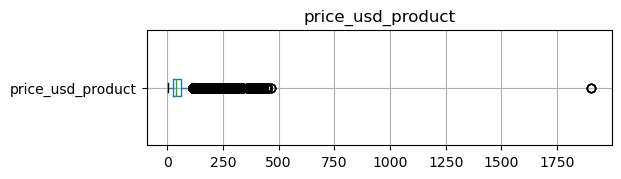

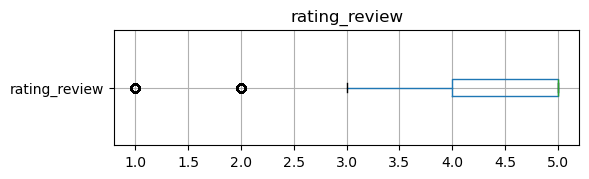

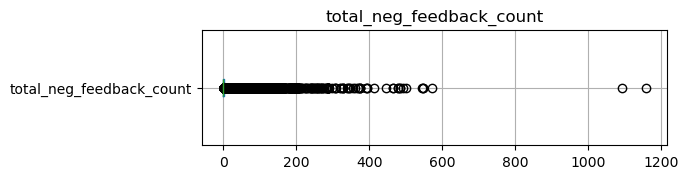

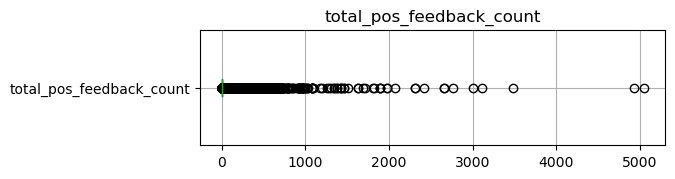

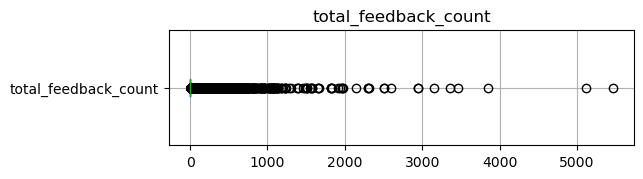

In [50]:
#checking for outliers using boxplot, for all neumerial variables:
import matplotlib.pyplot as plt

numeric_cols = ['price_usd_product', 'rating_review', 
                'total_neg_feedback_count', 'total_pos_feedback_count', 'total_feedback_count']

for col in numeric_cols:
    plt.figure(figsize=(6, 1.5))
    analysis_data.boxplot(column=col, vert=False)
    plt.title(col)
    plt.show()

#not relacing any outliers as they are viral or luxary products and removing them will result in information loss, so, will use scaling later on

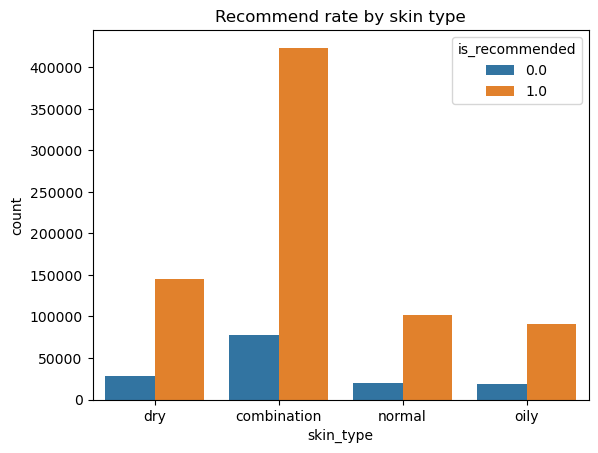

In [51]:
#checking visual relation between recommeded and skin type
sns.countplot(data=analysis_data, x='skin_type', hue='is_recommended')
plt.title('Recommend rate by skin type')
plt.show()

In [52]:
# proportion of recommended (1) vs not (0), within each skin type
rate_table = pd.crosstab(analysis_data['skin_type'], analysis_data['is_recommended'], normalize='index')
print(rate_table)

is_recommended       0.0       1.0
skin_type                         
combination     0.155206  0.844794
dry             0.163702  0.836298
normal          0.165672  0.834328
oily            0.166220  0.833780


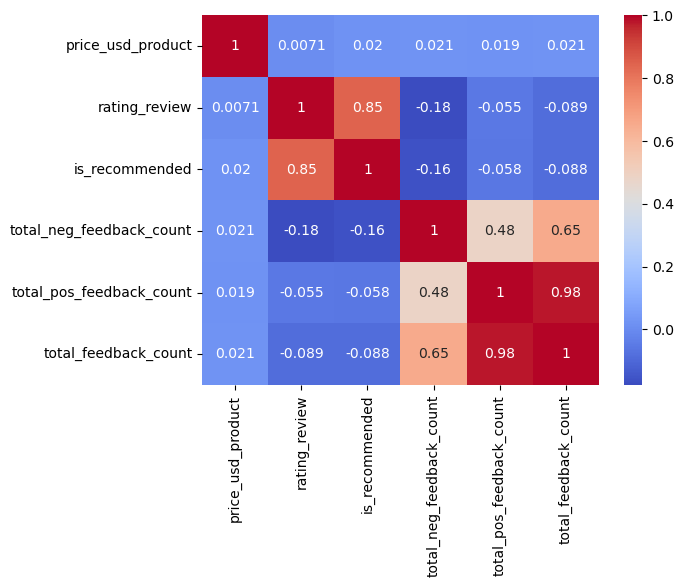

In [53]:
#checking collinearity

analysis_data.corr(numeric_only=True)
sns.heatmap(analysis_data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [54]:
#since these columns have high colliearity;dopping them 'total_neg_feedback_count', 'total_pos_feedback_count', 'total_feedback_count]

In [55]:
# features having high collinearlity dont help, rating_review and is_recommended had a 0.84 correlation in the heatmap, so dropping it,

In [56]:
#dropping these columns as well:

# product_name_product : unique identifier, no generalizable pattern (like product_id)
# ingredients : free text, out of scope 
# highlights : not being used as a feature in the current finalized scope
# review_text : free text, would need separate NLP treatment — out of scope for this version


In [58]:
cols_to_drop_2 = [
    'product_name_product',
    'ingredients',
    'highlights',
    'rating_review',
    'total_neg_feedback_count',
    'total_pos_feedback_count',
    'total_feedback_count',
    'review_text'
]

analysis_data = analysis_data.drop(columns=cols_to_drop_2)

In [61]:
analysis_data.columns.tolist()

['product_id',
 'brand_name_product',
 'price_usd_product',
 'skin_type',
 'skin_tone',
 'is_recommended']

In [66]:
print(analysis_data['skin_tone'].unique())

[nan 'light' 'lightMedium' 'fairLight' 'fair' 'medium' 'notSureST'
 'mediumTan' 'tan' 'rich' 'olive' 'deep' 'porcelain' 'dark' 'ebony']


In [67]:

analysis_data['skin_tone'] = analysis_data['skin_tone'].replace(
    {'NaN': 'unknown', 'notSureST': 'unknown'}
)
print(analysis_data['skin_tone'].unique())

[nan 'light' 'lightMedium' 'fairLight' 'fair' 'medium' 'unknown'
 'mediumTan' 'tan' 'rich' 'olive' 'deep' 'porcelain' 'dark' 'ebony']


In [68]:
# Splitting Train Test data before encoding or scaling as this avoids data leaks

In [69]:
#Defining Target and Features

#Target Variable : is_recommeneded

X = analysis_data.drop(columns=['is_recommended'])
y = analysis_data['is_recommended']

In [70]:
#train test split
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=analysis_data['product_id']))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (855258, 5)
Test shape: (239153, 5)


In [71]:
# Scaling and encoding features


In [73]:
#1. Scaling

In [79]:
# scaling the price column on a log scale, to better fit on regression/non tree models

In [84]:
# Price — log-transform, then scale, fit only on train
# log-transform first as price is heavily right-skewed ($3–$1,900), 
# log compresses that skew without discarding the luxury-item information

In [86]:
X_train['price_usd_log'] = np.log1p(X_train['price_usd_product'])
X_test['price_usd_log'] = np.log1p(X_test['price_usd_product'])   # transform, not a separate fit 
scaler = StandardScaler()
X_train['price_usd_scaled'] = scaler.fit_transform(X_train[['price_usd_log']])   # FIT on train
X_test['price_usd_scaled'] = scaler.transform(X_test[['price_usd_log']])         # TRANSFORM only on test; as you will use the mean and SD obtained from the train data

In [88]:
#2.Encoding the data: 

In [90]:
#The only 3 columns that need encoding are:
# 1 - skin_type - this is nominal variable, no order or ranking, so we use one hot encoding
# 2- skin_tone - this is ordinal, has a rank based on the lightness gradient, so we use ordinal encoding

# (using column transform to bundle the above two together)

# 3- brand_name_product - this is nominal, but creating 142 columns for each unique brand, causes high dimensionality, 
# therefor we encode it based on frequency - use one hot encoding using frequency


In [92]:
tone_order = [['unknown', 'porcelain', 'fair', 'fairLight', 'light', 'lightMedium',
               'medium', 'mediumTan', 'tan', 'olive', 'rich', 'deep', 'dark', 'ebony']]

oe = OrdinalEncoder(categories=tone_order, handle_unknown='use_encoded_value', unknown_value=-1)
X_train['skin_tone_encoded'] = oe.fit_transform(X_train[['skin_tone']])   # FIT on train
X_test['skin_tone_encoded'] = oe.transform(X_test[['skin_tone']])        # TRANSFORM only on test

In [94]:

ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

train_ohe = ohe.fit_transform(X_train[['skin_type']])   # FIT on train
test_ohe = ohe.transform(X_test[['skin_type']])         # TRANSFORM only on test

ohe_cols = ohe.get_feature_names_out(['skin_type'])
X_train[ohe_cols] = train_ohe
X_test[ohe_cols] = test_ohe

In [96]:
brand_freq = X_train['brand_name_product'].value_counts(normalize=True)   # calculated FROM TRAIN ONLY

X_train['brand_freq_encoded'] = X_train['brand_name_product'].map(brand_freq)
X_test['brand_freq_encoded'] = X_test['brand_name_product'].map(brand_freq).fillna(0)  
# any brand test has that train never saw → treated as "unknown/rare", frequency 0

In [98]:
#Dropping the now encoded original columns from both

In [100]:
drop_cols = ['skin_tone', 'skin_type', 'brand_name_product', 'price_usd_product', 'price_usd_log']

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

print(X_train.columns.tolist())
print(X_train.shape, X_test.shape)

['product_id', 'price_usd_scaled', 'skin_tone_encoded', 'skin_type_dry', 'skin_type_normal', 'skin_type_oily', 'skin_type_nan', 'brand_freq_encoded']
(855258, 8) (239153, 8)


In [102]:
#dropping Product ID
X_train_model = X_train.drop(columns=['product_id'])
X_test_model = X_test.drop(columns=['product_id'])

print(X_train_model.columns.tolist())

['price_usd_scaled', 'skin_tone_encoded', 'skin_type_dry', 'skin_type_normal', 'skin_type_oily', 'skin_type_nan', 'brand_freq_encoded']


In [109]:
print(y_train.value_counts(normalize=True))

is_recommended
1.0    0.843547
0.0    0.156453
Name: proportion, dtype: float64


In [106]:
#Training models